In [41]:
import matplotlib.pyplot as plt

from brian2 import *
import scienceplots

In [ ]:
DARK_BLUE  = (0.0, 0.4667, 0.7333)
LIGHT_BLUE = (0.2, 0.7333, 0.9333)
GREEN      = (0.0, 0.6, 0.5333)
ORANGE     = (0.9333, 0.4667, 0.2)
RED        = (0.8, 0.2, 0.0667)
PINK       = (0.9333, 0.2, 0.4667)
GRAY       = (0.7333, 0.7333, 0.7333)

SAVE = False

In [43]:
seed(0)

In [58]:
# --------------------- analytical ---------------------
# --- exact ----
def Z_term(tau_slow, T_ext):
    return tau_slow * (1 - np.exp(-T_ext / tau_slow))

def C3(z, T_ext, R0, u_ext, r_slow_0):
    return (z-T_ext) / R0 * np.pow(u_ext,3)

def C2(z, T_ext, R0, u_ext, r_slow_0):
    return (3*z - 2 * T_ext) * np.pow(u_ext, 2)

def C1(z, T_ext, R0, u_ext, r_slow_0):
    return (3*z * R0 - T_ext * R0 - z * r_slow_0 / R0) * u_ext

def C0(z, T_ext, R0, u_ext, r_slow_0):
    return z * (np.pow(R0, 2) - r_slow_0)

def r_slow_t(r_slow_0, T_ext, R0, u_ext, w, tau_slow):
    r_j_squared = np.pow((R0 + w * u_ext), 2)
    return r_j_squared - (r_j_squared - r_slow_0) * np.exp(- T_ext / tau_slow)

def delta_w(T_ext, R0, u_ext, r_slow_0, tau_slow, alpha, w):
    
    # stim 
    z = Z_term(tau_slow, T_ext)
    c3 = C3(z, T_ext, R0, u_ext, r_slow_0)
    c2 = C2(z, T_ext, R0, u_ext, r_slow_0)
    c1 = C1(z, T_ext, R0, u_ext, r_slow_0)
    c0 = C0(z, T_ext, R0, u_ext, r_slow_0)
    
    ri = R0 + u_ext
    trace_after_stim = r_slow_t(r_slow_0, T_ext, R0, u_ext, w, tau_slow)
    
    print(f"z: {z}")
    print(f"c3: {c3}")
    print(f"c2: {c2}")
    print(f"c1: {c1}")
    print(f"c0: {c0}")
    
    stim = alpha * ri * (c3 * np.pow(w, 3) + c2 * np.pow(w, 2) + c1 * w + c0)
    
    # after_stim 
    u_ext = 0
    T_ext *= 3
    r_slow_0 = trace_after_stim
    
    z = Z_term(tau_slow, T_ext)
    c3 = C3(z, T_ext, R0, u_ext, r_slow_0)
    c2 = C2(z, T_ext, R0, u_ext, r_slow_0)
    c1 = C1(z, T_ext, R0, u_ext, r_slow_0)
    c0 = C0(z, T_ext, R0, u_ext, r_slow_0)
    
    ri = R0
    
    after_stim = alpha * ri * (c3 * np.pow(w, 3) + c2 * np.pow(w, 2) + c1 * w + c0)
    
    return stim #+ after_stim

In [45]:
# ----------------------- Models -----------------------
# --- Brian Equations ---
eqs_neurons = '''
r = clip(u, 0 * Hz, 100 * Hz) : Hz
dr_slow/dt = 1 / Tau_slow * (-r_slow + r**2) : Hz*Hz
du/dt = 1 / Tau * (-u + u_syn + u_r + r_ext) : Hz
du_r/dt = - Theta_ur * (u_r - U_r0) + (Sigma_ur * xi)*Hz : Hz
r_ext : Hz
u_syn : Hz
sum_w : 1
X : metre (constant)
Y : metre (constant)
U_r0 : Hz (constant)
Theta_ur : Hz (constant)
Sigma_ur : Hz**0.5 (constant)
Tau : second (constant)
Tau_slow : second (constant)
'''

eqs_syn = '''
dw = r_pre/Hz * r_post/Hz * (r_post - theta) : Hz (constant over dt)
ddelta_w/dt = 1 / Tau_W * (dw - delta_w) : Hz (clock-driven)
dw/dt = Lr * clip(
    delta_w * (int(delta_w < 0*Hz) * int(w > 0.01) + int(delta_w > 0*Hz) * int(w < 1.5)), 
    -30*17*15/4*Hz, 30*17*15/4*Hz)
    # - 1 / C * int(sum_w_pre > W_sum_max * DEG) * int(w > 0.01) * (sum_w_pre - W_sum_max * DEG)
: 1 (clock-driven)
theta = r_slow_post / R_0 : Hz (constant over dt)
u_syn_post = w * r_pre : Hz (summed)
sum_w_pre = w : 1 (summed)
Lr : 1 (constant)
W_sum_max : 1 (constant)
R_0 : Hz (constant)
C : second (constant)
Tau_W : second (constant)
DEG : 1 (constant)
'''

In [46]:
DT_RECORD = 1*ms
LR = 1e-4

In [47]:
def init_network(w_init, n_inputs, t_init):
    all_neurons = NeuronGroup(n_inputs + 1, eqs_neurons, method='euler')
    input_neurons = all_neurons[:n_inputs]
    output_neuron = all_neurons[n_inputs]
    synapses = Synapses(input_neurons, output_neuron, eqs_syn, method='euler')
    synapses.connect()
    
    all_neurons.Tau_slow = 1000*ms
    all_neurons.Tau = 10*ms
    all_neurons.u = 2*Hz
    all_neurons.Theta_ur = 1*Hz
    
    input_neurons.U_r0 = 2*Hz
    output_neuron.U_r0 = 1*Hz
    
    synapses.R_0 = 2*Hz
    synapses.w = f'0.05*rand()'
    synapses.w[0] = w_init
    synapses.w[1:] = synapses.w[1:] / sum(synapses.w[1:]) * (0.5-w_init)
    synapses.Lr = LR
    synapses.Lr[0] = 0.
    synapses.Tau_W = 100*ms
    synapses.W_sum_max = 1.2
    synapses.C = 2_000*ms
    
    M = StateMonitor(all_neurons, ['r', 'r_slow'], record=True, dt=DT_RECORD)
    S = StateMonitor(synapses, ['w', 'theta', 'dw'], record=True, dt=DT_RECORD)
    
    net = Network(synapses, all_neurons, M, S)
    
    net.run(t_init)
    net.store("init_5_min")
    
    return net, input_neurons, output_neuron, synapses, M, S

def random_stimulation(network, tau_slow, restore=True, store=True):
    if restore:
        network["net"].restore("init_5_min")
    network["output_neuron"].Tau_slow = tau_slow
    network["synapses"].Lr[0] = LR
    network["input_neurons"][0:1].r_ext = 5*Hz
    network["net"].run(4*second)
    network["input_neurons"][0:1].r_ext = 0*Hz
    network["net"].run(5*second)
    if store:
        network["net"].store(f"post_random_{tau_slow/second:.2f}")
    return network["synapses"].w[0]
    
def sync_stimulation(network, tau_slow, t_after=5*second, restore=True, store=True):
    if restore:
        network["net"].restore("init_5_min")
    network["output_neuron"].Tau_slow = tau_slow
    network["synapses"].Lr[0] = LR
    network["input_neurons"][0:1].r_ext = 30*Hz
    network["net"].run(0.1*second)
    network["input_neurons"][0:1].r_ext = 0*Hz
    network["net"].run(t_after)
    network["net"].store(f"post_sync_{tau_slow/second:.2f}")
    return network["synapses"].w[0]

def gameplay_stimulation(network, tau_slow, t_stim=0.2*second, t_after=5*second, restore=True, store=True):
    if restore:
        network["net"].restore("init_5_min")
    network["output_neuron"].Tau_slow = tau_slow
    network["synapses"].Lr[0] = LR
    network["input_neurons"][0:1].r_ext = 7*Hz
    network["net"].run(t_stim)
    network["input_neurons"][0:1].r_ext = 0*Hz
    network["net"].run(t_after)
    if store:
        network["net"].store(f"post_gameplay_{tau_slow/second:.2f}")
    return network["synapses"].w[0]

In [48]:
w_grid = np.arange(0, 0.501, 0.1) #0.1, 0.15, 0.2, 0.25, 
networks = []
for w_stim in w_grid:
    net, input_neurons, output_neuron, synapses, M, S = init_network(w_stim, 10, 300*second)
    _dict = {"input_neurons" : input_neurons,
             "output_neuron" : output_neuron,
             "synapses" : synapses,
             "net" : net,
             "M" : M,
             "S" : S,
             "w_stim": w_stim
             }
    networks.append(_dict)

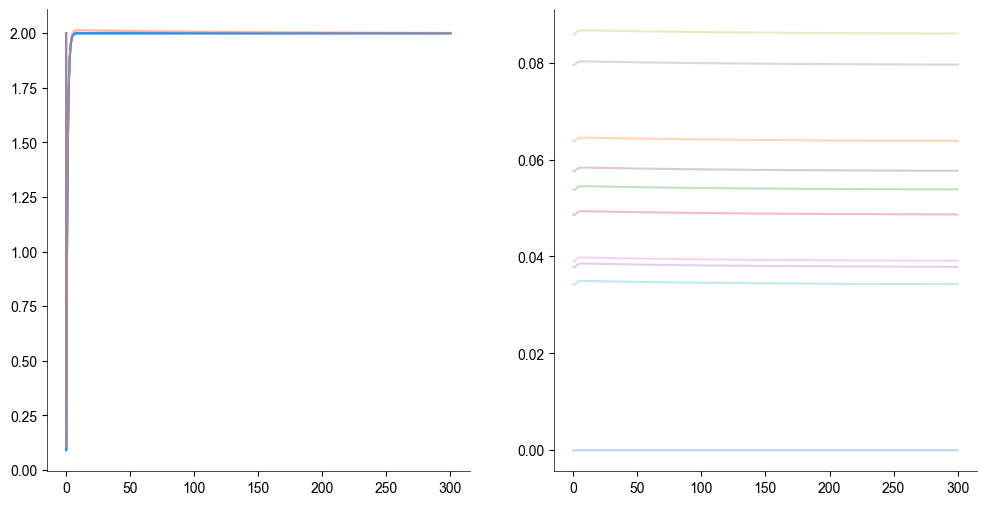

In [49]:
M = networks[0]["M"]
S = networks[0]["S"]

fig, axs = plt.subplots(1,2, figsize=(12,6))

axs[0].plot(M.t, M.r[:-1].T, alpha=0.3, color='dodgerblue', linewidth=1.5)
axs[0].plot(M.t, M.r[-1].T, alpha=0.6, color='coral', linewidth=1.5)
axs[1].plot(S.t, S.w.T, alpha=0.3, linewidth=1.5)

plt.show()

In [50]:
tau_slows = np.array([1])*second

delt_ws_random = zeros((tau_slows.size, w_grid.size))
delt_ws_sync = zeros_like(delt_ws_random)
delt_ws_gameplay = zeros_like(delt_ws_random)
for i, tau_slow in enumerate(tau_slows):
    for j, network in enumerate(networks):
        w_random = random_stimulation(network, tau_slow)
        # delt_ws_random[i,j] = np.sum(network['S'].dw[0][(network['S'].t >= 300*second) & (network['S'].t <= 316*second)]) * LR * DT_RECORD
        w_sync = sync_stimulation(network, tau_slow)
        # delt_ws_sync[i,j] = np.sum(network['S'].dw[0][(network['S'].t >= 300*second) & (network['S'].t <= 300.4*second)]) * LR * DT_RECORD
        # w_gp = gameplay_stimulation(network, tau_slow, t_stim=0.2*second, t_after=0.6*second)
        # delt_ws_gameplay[i,j] = np.sum(network['S'].dw[0][(network['S'].t >= 300*second) & (network['S'].t <= 300.8*second)]) * LR * DT_RECORD
        w_gameplay = gameplay_stimulation(network, tau_slow, t_stim=0.2*second)
        delt_ws_random[i,j] = w_random - network["w_stim"]
        delt_ws_sync[i,j] = w_sync - network["w_stim"]
        delt_ws_gameplay[i,j] = w_gameplay - network["w_stim"]
        

In [51]:
fs = np.arange(0, 31, 5)
ts = np.arange(0., 1.5, 0.1)
dw_stims = np.zeros((fs.size, ts.size))

for i, f in enumerate(fs):
    for j, t in enumerate(ts):
        dw_stims[i][j] = delta_w(t, 2, f, 4, 1, LR, 0.05) 

z: 0.0
c3: 0.0
c2: 0.0
c1: 0.0
c0: 0.0
z: 0.09516258196404048
c3: -0.0
c2: 0.0
c1: 0.0
c0: 0.0
z: 0.18126924692201818
c3: -0.0
c2: 0.0
c1: 0.0
c0: 0.0
z: 0.2591817793182821
c3: -0.0
c2: 0.0
c1: 0.0
c0: 0.0
z: 0.3296799539643607
c3: -0.0
c2: 0.0
c1: 0.0
c0: 0.0
z: 0.3934693402873666
c3: -0.0
c2: 0.0
c1: 0.0
c0: 0.0
z: 0.4511883639059736
c3: -0.0
c2: 0.0
c1: 0.0
c0: 0.0
z: 0.5034146962085906
c3: -0.0
c2: 0.0
c1: 0.0
c0: 0.0
z: 0.5506710358827784
c3: -0.0
c2: 0.0
c1: 0.0
c0: 0.0
z: 0.5934303402594009
c3: -0.0
c2: -0.0
c1: 0.0
c0: 0.0
z: 0.6321205588285577
c3: -0.0
c2: -0.0
c1: 0.0
c0: 0.0
z: 0.6671289163019205
c3: -0.0
c2: -0.0
c1: 0.0
c0: 0.0
z: 0.698805788087798
c3: -0.0
c2: -0.0
c1: 0.0
c0: 0.0
z: 0.7274682069659875
c3: -0.0
c2: -0.0
c1: 0.0
c0: 0.0
z: 0.7534030360583935
c3: -0.0
c2: -0.0
c1: 0.0
c0: 0.0
z: 0.0
c3: 0.0
c2: 0.0
c1: 0.0
c0: 0.0
z: 0.09516258196404048
c3: -0.3023386272474702
c2: 2.137193647303036
c1: 0.9032516392808096
c0: 0.0
z: 0.18126924692201818
c3: -1.170672067373864

In [52]:
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.ticker import ScalarFormatter

cmap = LinearSegmentedColormap.from_list(
    "red_white_green",
    [RED, "white", GREEN],
    N=256
)

vmax = np.max(np.abs(dw_stims))   # symmetric limits
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

z: 0.9816843611112658
c3: -188.64472743054588
c2: -126.37367291665507
c1: -20.366312777774684
c0: 0.0
z: 0.09516258196404048
c3: -65.30514348545356
c2: 76.9389713029093
c1: 5.419509835684858
c0: 0.0
z: 0.18126924692201818
c3: -3.2123241528738844
c2: 7.046579297536671
c1: 2.2755389138165087
c0: 0.0


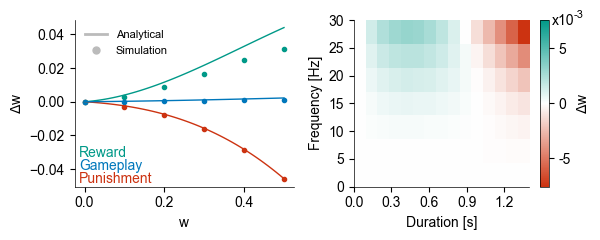

In [ ]:
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker

plt.style.use(['nature_d'])

fig, axs = plt.subplot_mosaic([["Traces", "FvsT"]])

w_grid_analytical = np.arange(0, 0.501, 0.01)

axs["Traces"].plot(w_grid_analytical,delta_w(4, 2, 5, 4, 1, LR, w_grid_analytical), color=RED, )
axs["Traces"].plot(w_grid_analytical,delta_w(0.1, 2, 30, 4, 1, LR, w_grid_analytical), color=GREEN,)
axs["Traces"].plot(w_grid_analytical,delta_w(0.2, 2, 7, 4, 1, LR, w_grid_analytical), color=DARK_BLUE)

axs["Traces"].scatter(w_grid, delt_ws_random, color=RED)
axs["Traces"].scatter(w_grid, delt_ws_sync.T, color=GREEN)
axs["Traces"].scatter(w_grid, delt_ws_gameplay.T, color=DARK_BLUE)

axs['Traces'].set_ylabel(r'$\Delta$w')
axs['Traces'].set_xlabel('w')


im = axs["FvsT"].imshow(
    dw_stims,
    aspect="auto",
    origin="lower",
    extent=[ts.min(), ts.max(), fs.min(), fs.max()],
    cmap=cmap,
    norm=norm
)

# Axis labels
axs["FvsT"].set_xlabel("Duration [s]")
axs["FvsT"].set_ylabel("Frequency [Hz]")

# Ticks
axs["FvsT"].set_xticks(ts)
axs["FvsT"].set_yticks(fs)

axs["FvsT"].set_xticks(ts[::3]) 

# Colorbar
cbar = fig.colorbar(im, ax=axs["FvsT"])
cbar.set_label(r'$\Delta$w')

# --- Scale tick labels by 10^3 ---
cbar.ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, pos: f"{x*1e3:.0f}")
)

# --- Add 10 and -3 as separate texts ---
# Base "10"
cbar.ax.text(
    1.4, 0.95,
    'x10',
    transform=cbar.ax.transAxes,
    ha='left',
    va='bottom'
)

# Exponent "-3" (shifted slightly up and right)
cbar.ax.text(
    4, 1.,
    '-3',
    transform=cbar.ax.transAxes,
    ha='left',
    va='bottom',
    fontsize=8
)

# --- Custom legend handles ---
legend_elements = [
    # Method legend (gray, generic)
    Line2D([0], [0], color=GRAY, lw=2, label='Analytical'),
    Line2D([0], [0], marker='o', linestyle='None', color=GRAY, markersize=5, label='Simulation'),
]
axs["Traces"].legend(handles=legend_elements, frameon=False, loc='upper left')

# # Bottom-left colored condition labels
axs["Traces"].text(
    0.02, 0.02,
    "Punishment",
    transform=axs["Traces"].transAxes,
    color=RED,
    ha='left'
)
axs["Traces"].text(
    0.02, 0.1,
    "Gameplay",
    transform=axs["Traces"].transAxes,
    color=DARK_BLUE,
    ha='left'
)
axs["Traces"].text(
    0.02, 0.18,
    "Reward",
    transform=axs["Traces"].transAxes,
    color=GREEN,
    ha='left'
)

fig.tight_layout()
if SAVE:
    fig.savefig("fig_4_AnaTest_FvsT.pdf", dpi=300)
plt.show()

In [60]:
76.9389713029093 * 1e-4

0.00769389713029093

In [55]:
delt_ws_random[0].shape

(6,)

In [56]:
w_grid - delt_ws_random

array([[0.        , 0.10283985, 0.20815015, 0.31644321, 0.42848916,
        0.54601804]])